In [29]:
from Bio.PDB import PDBParser, Superimposer, PDBIO
import matplotlib.pyplot as plt
import numpy as np
from pymol import cmd
import pandas as pd
import os

In [30]:
# def get_sequence_length_in_pdb(pdb_file):
#     # Initialize PDB parser
#     parser = PDBParser(QUIET=True)

#     # Parse the PDB file
#     structure = parser.get_structure("structure", pdb_file)

#     # Initialize variables to store chain information
#     chain_lengths = {}

#     # Iterate over chains in the first model
#     for chain in structure[0]:
#         chain_id = chain.id
#         # Count residues in the chain
#         residues = [res for res in chain if res.id[0] == " "]  # Exclude heteroatoms
#         if len(residues) > 0:
#             chain_lengths[chain_id] = len(residues)

#     # Print the results
#     # print(f"Number of chains: {len(chain_lengths)}")
#     for k,v in chain_lengths.items():
#         # print(k,v)
#         pass
#     if len(chain_lengths) > 1:
#         raise ValueError("Multiple chains detected. It should only be one...")
    
#     for chain_id, length in chain_lengths.items():
#         return length
    
# def get_sequence_length_from_pdb_from_pymol(pdb_file, chain_id=None):
#     """
#     Reads a PDB file, loads it into PyMOL, and calculates the sequence length.
    
#     Parameters:
#         pdb_file (str): Path to the PDB file.
#         chain_id (str, optional): Specific chain to calculate the sequence length for.
#                                   If None, calculates for all chains.
    
#     Returns:
#         dict: Dictionary of chain IDs and their sequence lengths.
#     """
#     # print("PDB file for sequence length", pdb_file)
#     # Load the PDB file into PyMOL
#     cmd.load(pdb_file, "structure")
    
#     # Initialize a dictionary to store sequence lengths
#     sequence_lengths = {}
    
#     # Get chains
#     chains = cmd.get_chains("structure")
    
#     # Iterate through chains to calculate sequence lengths
#     for chain in chains:
#         if chain_id is None or chain == chain_id:
#             # Get unique residues in the chain
#             residues = cmd.get_model(f"structure and chain {chain} and name CA").atom
#             unique_residues = {atom.resi for atom in residues}
            
#             # Store the length in the dictionary
#             sequence_lengths[chain] = len(unique_residues)
    
#     # Clean up PyMOL session
#     cmd.delete("structure")
    
#     return sequence_lengths

# def align_structure(reference_file, mobile_file):

#     root = '.'
#     reference_name = os.path.basename(reference_file).split(".pdb")[0]
#     mobile_name = os.path.basename(mobile_file).split(".pdb")[0]

#     # Define file paths and parameters
#     full_structure_file = reference_file
#     subset_structure_file = mobile_file

#     # Sequence lengths...
#     n_res_ref = get_sequence_length_in_pdb(full_structure_file)
#     n_res_mob = get_sequence_length_in_pdb(subset_structure_file)
#     n_res_mob2 = get_sequence_length_from_pdb_from_pymol(subset_structure_file)

#     # Define the residue range in the full structure that corresponds to the subset
#     df = pd.read_csv(os.path.join(root, "..", "processed", "trna_synthetases_data.csv"))
#     mobile_file_name = os.path.basename(mobile_file)
#     start_residue = df[df["file_name"] == mobile_file_name]["start_resid"].values[0]
#     end_residue = df[df["file_name"] == mobile_file_name]["end_resid"].values[0]

#     # Load the structures
#     parser = PDBParser(QUIET=True)
#     full_structure = parser.get_structure(reference_name, full_structure_file)
#     subset_structure = parser.get_structure(mobile_name, subset_structure_file)

#     # Select Cα atoms from the full structure (corresponding to the subset region)
#     ref_atoms = [
#         residue["CA"] for residue in full_structure[0]["A"]
#         if start_residue <= residue.id[1] <= end_residue
#     ]

#     # Select Cα atoms from the subset structure
#     chain_id = list(subset_structure[0])[0].get_id()
#     try:
#         sample_atoms = [
#             residue["CA"] for residue in subset_structure[0][chain_id]
#             if start_residue <= residue.id[1] <= end_residue
#         ]
#     except:
#         for residue in subset_structure[0][chain_id]:
#             print(residue)

#     print(len(ref_atoms), len(sample_atoms))

#     # Perform the superimposition
#     super_imposer = Superimposer()
#     super_imposer.set_atoms(ref_atoms, sample_atoms)
#     super_imposer.apply(subset_structure.get_atoms())

#     # Print the RMSD value
#     print(f"RMSD: {super_imposer.rms:.4f} Å")

#     return float(round(super_imposer.rms, 2))

In [31]:
# def align_structure_with_pymol(reference_file, mobile_file):

#     # Extract base names for the reference and mobile structure files
#     reference_name = os.path.basename(reference_file).split(".pdb")[0]
#     mobile_name = os.path.basename(mobile_file).split(".pdb")[0]

#     # Load both structures into PyMOL
#     cmd.reinitialize()
#     cmd.load(reference_file, reference_name)
#     cmd.load(mobile_file, mobile_name)

#     # Perform the alignment using PyMOL's super command
#     alignment_result = cmd.super(mobile_name, reference_name)

#     # Extract RMSD value (first element in the result tuple)
#     rmsd = round(alignment_result[0], 2)

#     return rmsd


In [32]:
# PATH_TO_STRUCTURES = "../processed/aligned_relaxed_structures"
# PATH_TO_OUTPUT = "../processed/structural_comparisons"

# os.makedirs(PATH_TO_OUTPUT, exist_ok=True)

# for uni1, uni2 in uni_pairs[1:]:

#     print(uni1, uni2)
#     results = dict()

#     # Get associated structures
#     sts1 = uniprot_to_filename[uni1]
#     sts2 = uniprot_to_filename[uni2]

#     # Get paths to sts
#     sts1 = [os.path.join(PATH_TO_STRUCTURES, uni1, i) for i in sts1]
#     sts2 = [os.path.join(PATH_TO_STRUCTURES, uni2, i) for i in sts2]

#     # For each structure pair
#     for st1 in sts1:
#         for st2 in sts2:

#             # Calculate RMSD
#             rmsd = align_structure_with_pymol(st1, st2)
#             results[(os.path.basename(st1), os.path.basename(st2))] = rmsd

#     # Save results to CSV
#     results_df = pd.DataFrame([[i[0], i[1], results[i]] for i in sorted(results)], columns=["file_name_1", "file_name_2", "rmsd"])
#     results_df.to_csv(os.path.join(PATH_TO_OUTPUT, f"{uni1}_{uni2}_rmsd.csv"), index=False)


In [61]:
# Dict mapping uniprot to filename
df = pd.read_csv("../processed/alignment_relaxed_rmsd_data.csv")
uniprots = sorted(set(df["uniprot_ac"]))
uniprot_to_filename = {i: sorted(df[df['uniprot_ac'] == i]['file_name']) for i in uniprots}

# Get all possible uniprot pairs
uni_pairs = [(i,j) for i in uniprots for j in uniprots]

# Load Min RMSDs (if available)
PATH_TO_RMSDs = "../processed/structural_comparisons"
uni_pair_to_rmsd = {}
for uni_pair in uni_pairs:
    try:
        df = pd.read_csv(os.path.join(PATH_TO_RMSDs, f"{uni_pair[0]}_{uni_pair[1]}_rmsd.csv"))
        uni_pair_to_rmsd[uni_pair] = min(df["rmsd"])
    except:
        pass

# Create empty matrix
X = np.zeros((len(uniprots), len(uniprots)))

# Fill the matrix with RMSD values
for i in range(len(uniprots)):
    for j in range(len(uniprots)):
        uni_pair = (uniprots[i], uniprots[j])
        if uni_pair in uni_pair_to_rmsd:
            X[i, j] = uni_pair_to_rmsd[uni_pair]

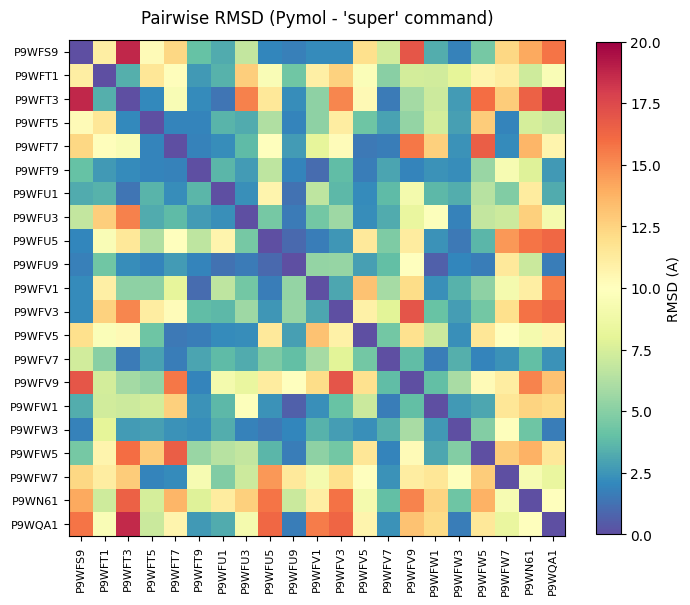

In [62]:
size = 8
plt.figure(figsize=(8, 8))
plt.imshow(X, vmin=0, vmax=20, cmap='Spectral_r')
plt.xticks(range(len(uniprots)), uniprots, rotation=90, size=size)
plt.yticks(range(len(uniprots)), uniprots, size=size)
plt.title("Pairwise RMSD (Pymol - 'super' command)", pad=12)
plt.colorbar(shrink=0.8, label="RMSD (A)")
plt.show()

In [63]:
import seaborn as sns

/home/acomajuncosa/miniconda3/envs/adda4tb/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/acomajuncosa/miniconda3/envs/adda4tb/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


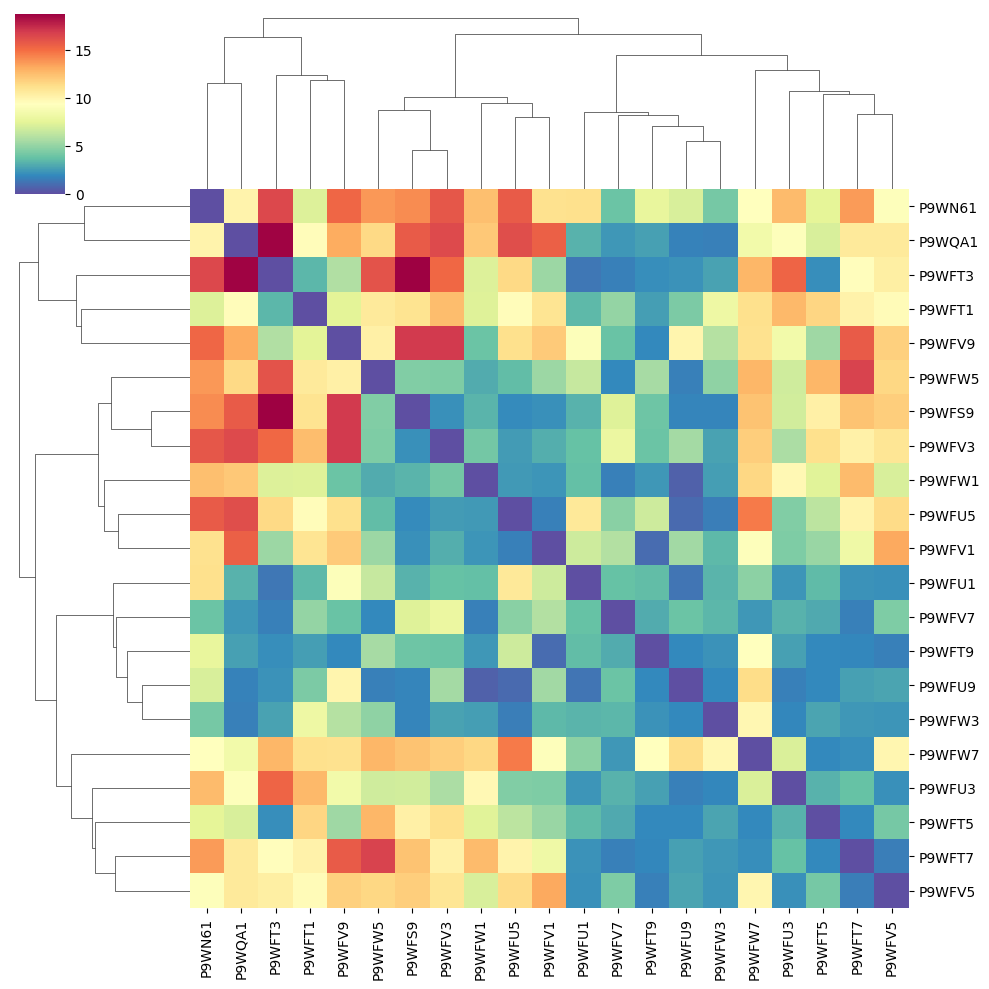

In [64]:
df = pd.DataFrame(X, columns=[f'{uniprots[i]}' for i in range(X.shape[1])],
                     index=[f'{uniprots[i]}' for i in range(X.shape[0])])

# Plot the clustermap
sns.clustermap(df, cmap="Spectral_r")
plt.show()